In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [3]:
import zipfile
import os

with zipfile.ZipFile("archive (2).zip", 'r') as zip_ref:
    zip_ref.extractall(".")

print(os.listdir("."))

['.config', 'matches.csv', 'deliveries.csv', 'archive (2).zip', 'sample_data']


In [4]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
print(matches.head())

Matches shape: (636, 18)
Deliveries shape: (150460, 21)
   id  season       city        date                        team1  \
0   1    2017  Hyderabad  2017-04-05          Sunrisers Hyderabad   
1   2    2017       Pune  2017-04-06               Mumbai Indians   
2   3    2017     Rajkot  2017-04-07                Gujarat Lions   
3   4    2017     Indore  2017-04-08       Rising Pune Supergiant   
4   5    2017  Bangalore  2017-04-08  Royal Challengers Bangalore   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   
3              Kings XI Punjab              Kings XI Punjab         field   
4             Delhi Daredevils  Royal Challengers Bangalore           bat   

   result  dl_applied                       winner  win_by_runs  \

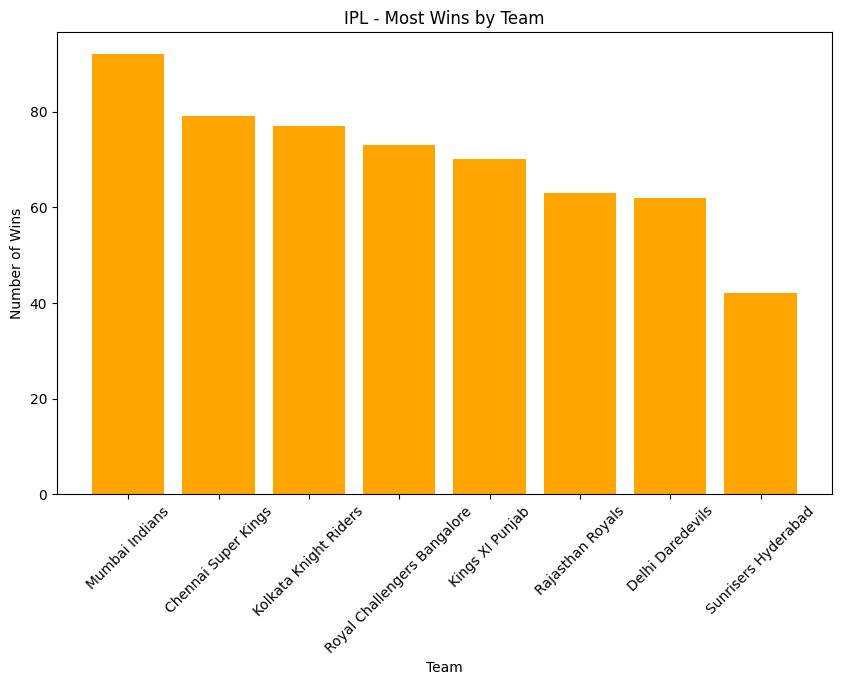

In [5]:
# Most wins by team
top_teams = matches['winner'].value_counts().head(8)

plt.figure(figsize=(10,6))
plt.bar(top_teams.index, top_teams.values, color='orange')
plt.title('IPL - Most Wins by Team')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.show()

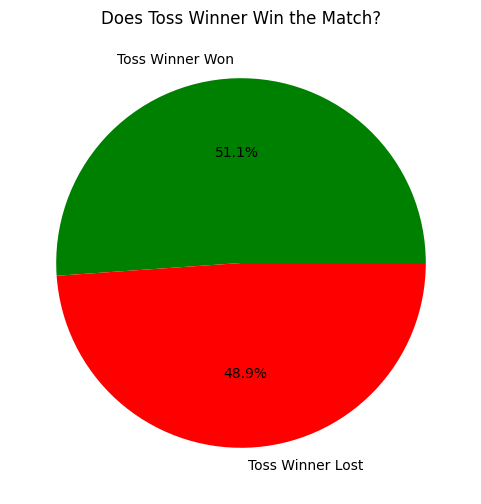

In [6]:
# Toss winner vs Match winner
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']

toss_impact = matches['toss_match_winner'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(toss_impact.values,
        labels=['Toss Winner Won', 'Toss Winner Lost'],
        autopct='%1.1f%%',
        colors=['green','red'])
plt.title('Does Toss Winner Win the Match?')
plt.show()

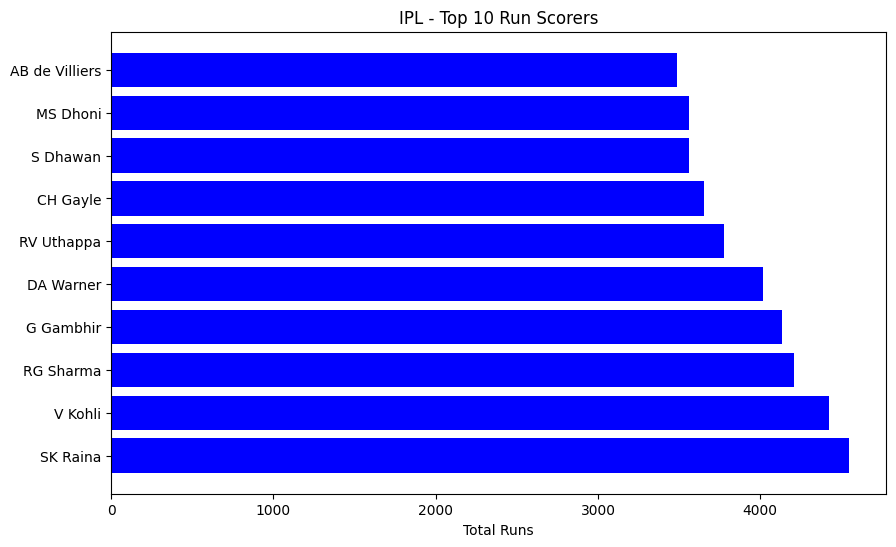

In [7]:
# Top 10 run scorers
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_batsmen.index, top_batsmen.values, color='blue')
plt.title('IPL - Top 10 Run Scorers')
plt.xlabel('Total Runs')
plt.show()

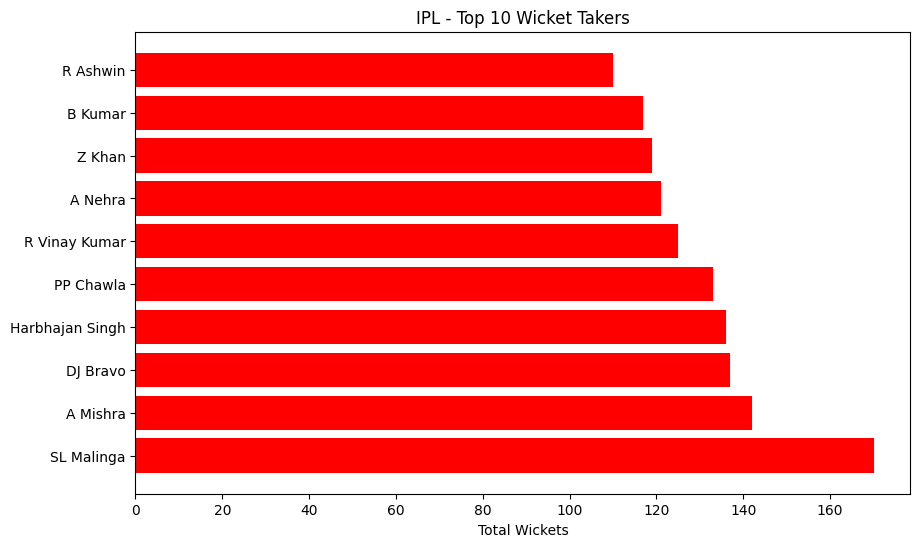

In [8]:
# Top 10 wicket takers
wickets = deliveries[deliveries['player_dismissed'].notna()]
top_bowlers = wickets.groupby('bowler')['player_dismissed'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_bowlers.index, top_bowlers.values, color='red')
plt.title('IPL - Top 10 Wicket Takers')
plt.xlabel('Total Wickets')
plt.show()

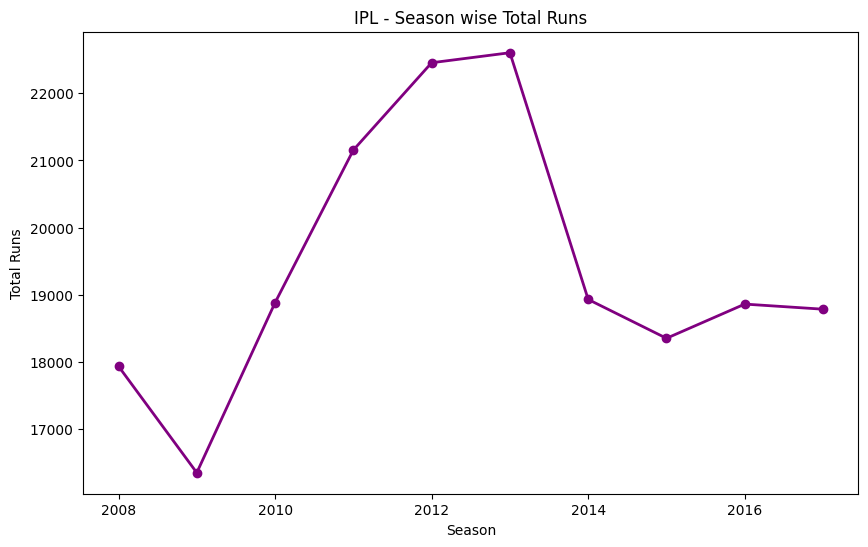

In [9]:
# Season wise total runs
season_runs = deliveries.merge(matches[['id','season']], left_on='match_id', right_on='id')
season_total = season_runs.groupby('season')['total_runs'].sum()

plt.figure(figsize=(10,6))
plt.plot(season_total.index, season_total.values, color='purple', marker='o', linewidth=2)
plt.title('IPL - Season wise Total Runs')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.show()